In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

master_path = "../data/master_workbook.xlsx"

# Fixed Income Treasury Analysis Workbook


## What is your argument?​
This is a short paragraph of your perspective of how SMIF should manage its holdings. Should the fund
overweight, underweight, or maintain and equal weight of your ass class? If we overweight or underweight this
asset class, what are your reason for adjusting the weightings compared to our benchmark. If we overweight or
underweight your asset class, what other asset class should be overweighted or underweighted? Why should we
make this change to the SMIF portfolio holdings? If the SMIF should hold and equal weight, why? How does your
recommendation better prepare the SMIF Fixed Income Portfolio for the future? Does your recommendation keep
the SMIF Fixed Income Portfolio within the Fund Mandate? Below, include two graphs with one showing the
current SMIF holdings, as well as what the holdings would look like if SMIF accepted your recommendation and
highlight those differences. Add any metrics that would add color.​


** Need to get SMIF's current performance vs the benchmark

`Get from Bloomberg`

## Benchmark Overview
Provide a breakdown of the benchmark. What is the asset, maturity, and duration breakdown of the benchmark? Discuss any relevant metrics. Include a graph of the benchmark. Briefly discuss your benchmark’s performance on a total return basis. Briefly, bring attention to your asset class, its allocation, and how it has performed within the benchmark. Discuss the asset class’s duration and maturity and how it impacts the benchmark.

In [2]:
df_ticker = yf.Ticker("AGG").history(period="5y")
print(df_ticker.tail())
df_ticker.index = df_ticker.index.tz_localize(None)

                                Open       High        Low      Close  \
Date                                                                    
2026-03-25 00:00:00-04:00  99.150002  99.209999  99.000000  99.110001   
2026-03-26 00:00:00-04:00  98.839996  98.970001  98.550003  98.550003   
2026-03-27 00:00:00-04:00  98.339996  98.669998  98.290001  98.540001   
2026-03-30 00:00:00-04:00  99.029999  99.199997  98.949997  99.040001   
2026-03-31 00:00:00-04:00  99.279999  99.474998  99.180099  99.285004   

                             Volume  Dividends  Stock Splits  Capital Gains  
Date                                                                         
2026-03-25 00:00:00-04:00  16242700        0.0           0.0            0.0  
2026-03-26 00:00:00-04:00  12299400        0.0           0.0            0.0  
2026-03-27 00:00:00-04:00  15511300        0.0           0.0            0.0  
2026-03-30 00:00:00-04:00  12882500        0.0           0.0            0.0  
2026-03-31 00:00:00-

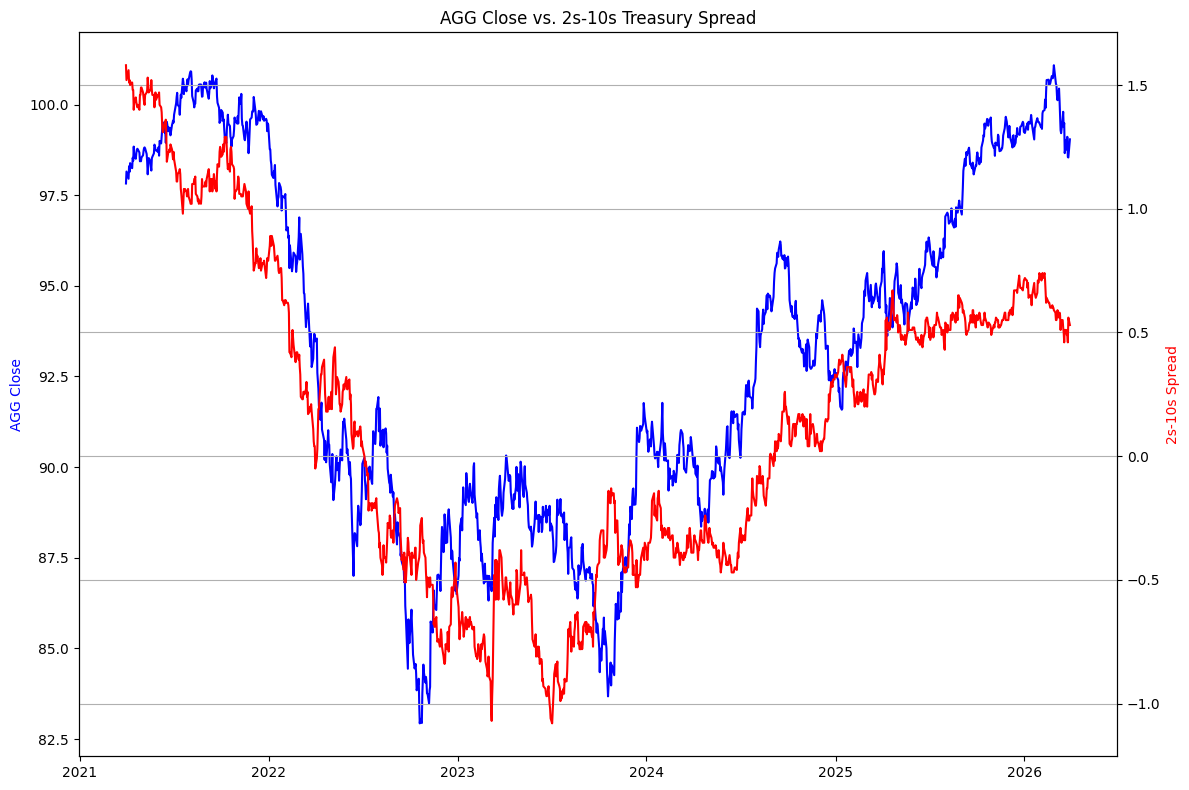

In [3]:
# Pull other macro indicators from the master workbook
df_master = pd.read_excel(master_path, sheet_name="All Data", index_col="date", skiprows=1)

merged = df_ticker.join(df_master, how="inner")

t_axis = merged.index

fig, ax1 = plt.subplots(figsize=(12, 8))
ax1.plot(t_axis, merged["Close"], color="blue", label="AGG Close")
ax1.set_ylabel("AGG Close", color="blue")

ax2 = ax1.twinx()
ax2.plot(t_axis, merged["T10Y2Y"], color="red", label="2s-10s")
ax2.set_ylabel("2s-10s Spread", color="red")

plt.title("AGG Close vs. 2s-10s Treasury Spread")
fig.tight_layout()
plt.grid()
plt.show();

Mean: 0.0011651635644920318, Standard Deviation: 0.3468997408212644


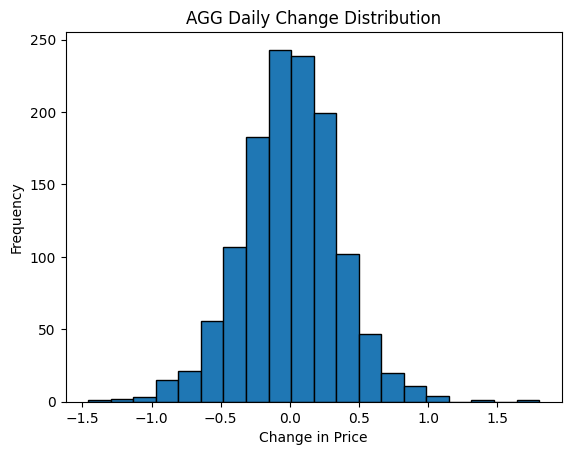

In [4]:
change = [df_ticker["Close"].iloc[i+1] - df_ticker["Close"].iloc[i] for i in range(0, len(df_ticker)-1)]

def calc_mean():
    return sum(change) / len(change)

def calc_std_dev():
    mean = calc_mean()
    variance = sum((x - mean) ** 2 for x in change) / len(change)
    return variance ** 0.5

std_dev, mean = calc_std_dev(), calc_mean()
print(f"Mean: {mean}, Standard Deviation: {std_dev}")

plt.hist(change, bins=20, edgecolor='black')
plt.title("AGG Daily Change Distribution")
plt.xlabel("Change in Price")
plt.ylabel("Frequency")
plt.show()


## Benchmark Comparison
Compare the SMIF Fixed Income Holdings compared to the benchmark's holdings. How does the SMIF Fixed Income holding compare to the benchmark holdings. Discuss duration, total return performance, and any other metrics that are relevant. Discuss how the SMIF Fixed Income Portfolio is positioned to take advantage of market factors. Provide a graph of the SMIF Fixed Income Holdings. Then, briefly, bring attention to your asset class, its allocation, and how it has preformed within the SMIF Fixed Income Portfolio. Discuss the asset class’s duration and maturity and how this affects the SMIF Fixed Income Holdings.

=== AGG Benchmark Summary ===
Latest Close:          $99.29
YTD Price Return:      0.07%
1-Year Price Return:   4.38%
3-Year Price Return:   11.82%
Est. Modified Duration: ~6.3 yrs
Est. DV01 (per $100):  $0.0625  (price drops ~$0.063 per 1bp rate rise)


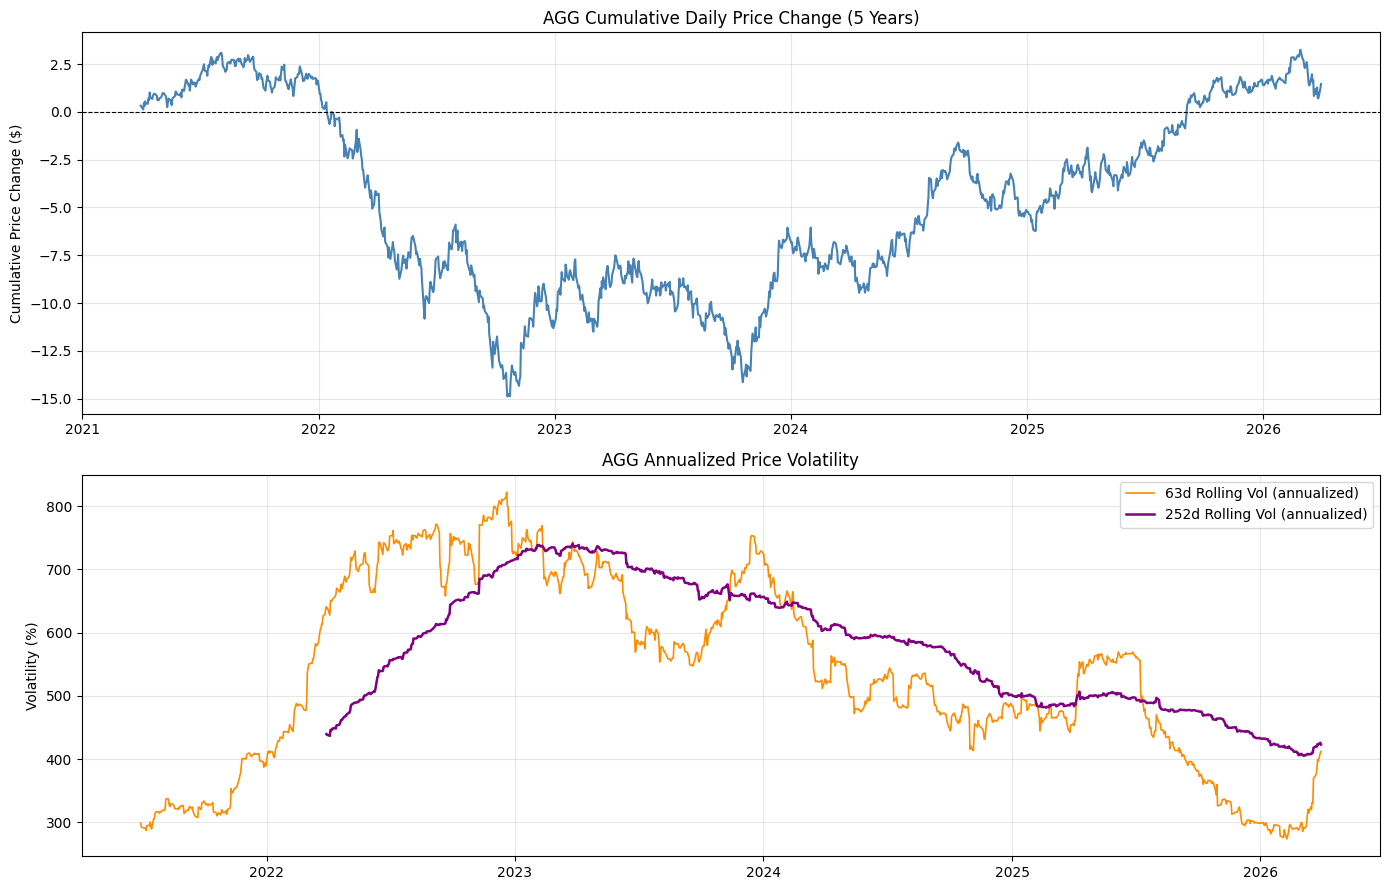

In [5]:
# Benchmark Comparison: AGG performance metrics and rolling risk
# AGG approximate modified duration ~6.3 years (varies; check Bloomberg for live figure)
agg_duration_est = 6.3

# Price return summary
ytd_start = df_ticker[df_ticker.index >= f"{df_ticker.index[-1].year}-01-01"]["Close"].iloc[0]
ytd_return = (df_ticker["Close"].iloc[-1] / ytd_start - 1) * 100
one_yr_return = (df_ticker["Close"].iloc[-1] / df_ticker["Close"].iloc[-252] - 1) * 100
three_yr_return = (df_ticker["Close"].iloc[-1] / df_ticker["Close"].iloc[-756] - 1) * 100 if len(df_ticker) > 756 else np.nan

print("=== AGG Benchmark Summary ===")
print(f"Latest Close:          ${df_ticker['Close'].iloc[-1]:.2f}")
print(f"YTD Price Return:      {ytd_return:.2f}%")
print(f"1-Year Price Return:   {one_yr_return:.2f}%")
print(f"3-Year Price Return:   {three_yr_return:.2f}%" if not np.isnan(three_yr_return) else "3-Year: N/A")
print(f"Est. Modified Duration: ~{agg_duration_est} yrs")
dv01 = agg_duration_est * df_ticker["Close"].iloc[-1] / 100 * 0.01
print(f"Est. DV01 (per $100):  ${dv01:.4f}  (price drops ~${dv01:.3f} per 1bp rate rise)")

# Rolling annualized volatility
returns_series = pd.Series(change, index=df_ticker.index[1:])
rolling_vol_63 = returns_series.rolling(63).std() * np.sqrt(252)
rolling_vol_252 = returns_series.rolling(252).std() * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(df_ticker.index[1:], returns_series.cumsum(), color='steelblue', linewidth=1.5)
axes[0].set_title("AGG Cumulative Daily Price Change (5 Years)")
axes[0].set_ylabel("Cumulative Price Change ($)")
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_ticker.index[1:], rolling_vol_63 * 100, color='darkorange', linewidth=1.2, label='63d Rolling Vol (annualized)')
axes[1].plot(df_ticker.index[1:], rolling_vol_252 * 100, color='purple', linewidth=1.8, label='252d Rolling Vol (annualized)')
axes[1].set_title("AGG Annualized Price Volatility")
axes[1].set_ylabel("Volatility (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Opportunities
What opportunities are present in your asset class?
Macroeconomic Tailwinds such inflation and GDP Growth
Monetary Policy such as interest rates, QE, and QT
Supply and Demand for this asset class. Supply meaning new issuances and demand meaning the demand for these issuances

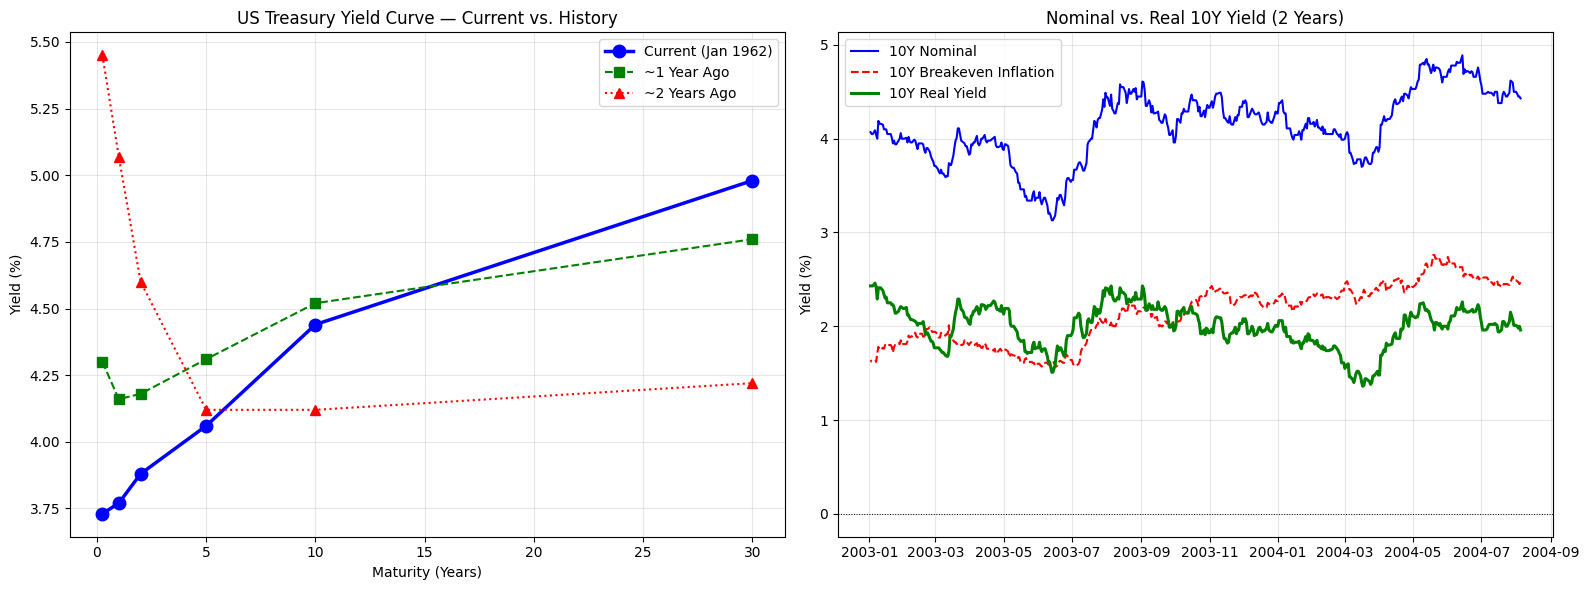


=== Current Yield Curve ===
  3M  : 3.73%
  1Y  : 3.77%
  2Y  : 3.88%
  5Y  : 4.06%
  10Y : 4.44%
  30Y : 4.98%

2s-10s Spread:          +0.68%
10Y-3M Spread:          +2.32%
10Y Breakeven:          1.64%
 5Y Breakeven:          1.30%
5Y5Y Forward Inflation: 1.98%
10Y Real Yield:         2.43%


In [6]:
# Opportunities: Yield curve snapshot + real yield analysis (nominal - breakeven inflation)
tenors = ['DGS3MO', 'DGS1', 'DGS2', 'DGS5', 'DGS10', 'DGS30']
labels = ['3M', '1Y', '2Y', '5Y', '10Y', '30Y']
maturities = [0.25, 1, 2, 5, 10, 30]

# Latest available observation for each tenor
curve_now  = [df_master[t].dropna().iloc[0] for t in tenors]
curve_1y   = [df_master[t].dropna().iloc[365] if len(df_master[t].dropna()) > 252 else np.nan for t in tenors]
curve_2y   = [df_master[t].dropna().iloc[2*365] if len(df_master[t].dropna()) > 504 else np.nan for t in tenors]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Yield curve snapshot
axes[0].plot(maturities, curve_now, 'o-', color='blue', linewidth=2.5, markersize=9,
             label=f'Current ({df_master["DGS10"].dropna().index[-1].strftime("%b %Y")})')
axes[0].plot(maturities, curve_1y,  's--', color='green', linewidth=1.5, markersize=7, label='~1 Year Ago')
axes[0].plot(maturities, curve_2y,  '^:', color='red',   linewidth=1.5, markersize=7, label='~2 Years Ago')
axes[0].set_title("US Treasury Yield Curve — Current vs. History")
axes[0].set_xlabel("Maturity (Years)")
axes[0].set_ylabel("Yield (%)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Real yield = nominal - breakeven inflation
t10_nom = df_master['DGS10'].dropna()
t10be   = df_master['T10YIE'].dropna()
t5be    = df_master['T5YIE'].dropna()
common_idx = t10_nom.index.intersection(t10be.index)
real_10y = t10_nom[common_idx] - t10be[common_idx]

window = 504  # ~2 years
axes[1].plot(common_idx[-window:], t10_nom[common_idx][-window:], color='blue',  linewidth=1.5, label='10Y Nominal')
axes[1].plot(common_idx[-window:], t10be[common_idx][-window:],   color='red',   linewidth=1.5, linestyle='--', label='10Y Breakeven Inflation')
axes[1].plot(common_idx[-window:], real_10y[-window:],            color='green', linewidth=2.2, label='10Y Real Yield')
axes[1].axhline(0, color='black', linewidth=0.7, linestyle=':')
axes[1].set_title("Nominal vs. Real 10Y Yield (2 Years)")
axes[1].set_ylabel("Yield (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Current Yield Curve ===")
for lbl, rate in zip(labels, curve_now):
    print(f"  {lbl:4s}: {rate:.2f}%")

spread_2s10s = df_master['T10Y2Y'].dropna().iloc[-1]
spread_10y3m = df_master['T10Y3M'].dropna().iloc[-1]
be_10y = df_master['T10YIE'].dropna().iloc[-1]
be_5y  = df_master['T5YIE'].dropna().iloc[-1]
fwd_5y5y = df_master['T5YIFR'].dropna().iloc[-1]

print(f"\n2s-10s Spread:          {spread_2s10s:+.2f}%")
print(f"10Y-3M Spread:          {spread_10y3m:+.2f}%")
print(f"10Y Breakeven:          {be_10y:.2f}%")
print(f" 5Y Breakeven:          {be_5y:.2f}%")
print(f"5Y5Y Forward Inflation: {fwd_5y5y:.2f}%")
print(f"10Y Real Yield:         {real_10y.iloc[-1]:.2f}%")

## Risks
What risks are present in your asset class?
Macroeconomic Headwinds such inflation and GDP Growth
Monetary Policy such as interest rates, QE, and QT
Supply and Demand for this asset class. Supply meaning new issuances and demand meaning the demand for these issuances

=== Duration Risk: Estimated Price Impact of Parallel Rate Shocks ===
  (Per $100 face value, assumes flat shift; actual impact varies by coupon/maturity)

Tenor  Mod Dur   +  25bps  +  50bps  + 100bps  + 200bps  
-------------------------------------------------------------
3M     0.25         -0.06%     -0.12%     -0.25%     -0.50%  
1Y     0.97         -0.24%     -0.48%     -0.97%     -1.94%  
2Y     1.93         -0.48%     -0.96%     -1.93%     -3.86%  
5Y     4.65         -1.16%     -2.33%     -4.65%     -9.30%  
10Y    8.80         -2.20%     -4.40%     -8.80%    -17.60%  
30Y    17.50        -4.38%     -8.75%    -17.50%    -35.00%  


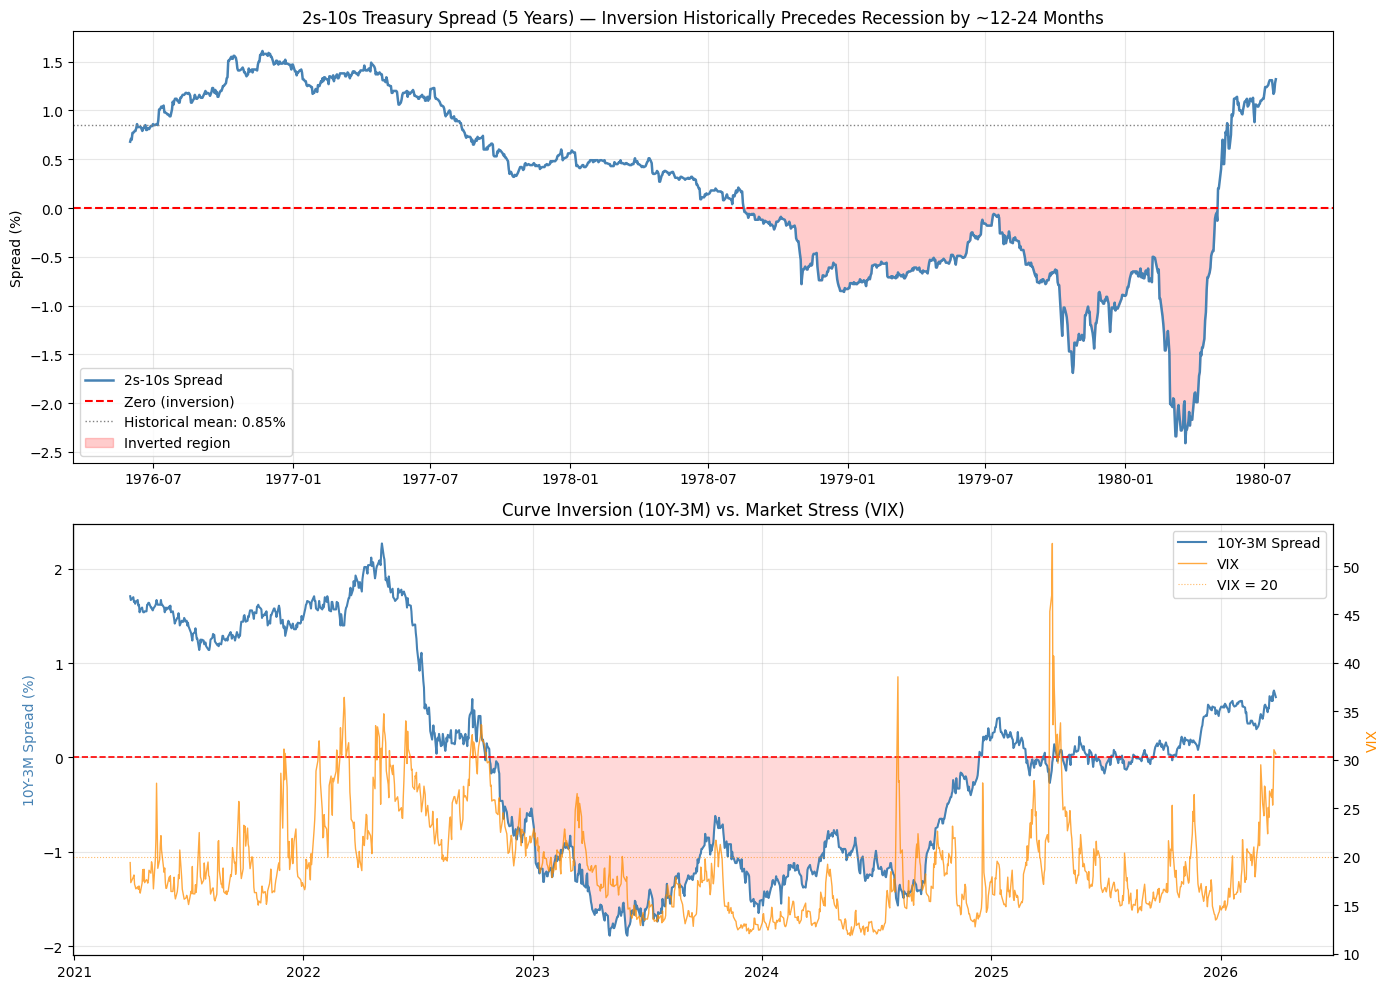

In [7]:
# Risks: Duration risk table + curve inversion history + financial stress overlay
durations = {'3M': 0.25, '1Y': 0.97, '2Y': 1.93, '5Y': 4.65, '10Y': 8.8, '30Y': 17.5}

print("=== Duration Risk: Estimated Price Impact of Parallel Rate Shocks ===")
print(f"  (Per $100 face value, assumes flat shift; actual impact varies by coupon/maturity)\n")
shocks = [25, 50, 100, 200]
header = f"{'Tenor':<6} {'Mod Dur':<10}" + "".join([f"+{s:>4}bps  " for s in shocks])
print(header)
print("-" * (len(header) + 4))
for lbl, dur in durations.items():
    row = f"{lbl:<6} {dur:<10.2f}" + "".join([f"{-dur*s/100:>+8.2f}%  " for s in shocks])
    print(row)

# Curve inversion as a leading recession indicator
t2y10 = df_master['T10Y2Y'].dropna()
t3m10 = df_master['T10Y3M'].dropna()

# Pull VIX from yfinance and strip timezone so index aligns with FRED dates
vix = yf.Ticker("^VIX").history(period="5y")["Close"].dropna()
vix.index = vix.index.tz_localize(None)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 2s10s with inversion shading
axes[0].plot(t2y10.index[-1260:], t2y10[-1260:], color='steelblue', linewidth=1.8, label='2s-10s Spread')
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--', label='Zero (inversion)')
axes[0].axhline(t2y10.mean(), color='gray', linewidth=1, linestyle=':', label=f'Historical mean: {t2y10.mean():.2f}%')
axes[0].fill_between(t2y10.index[-1260:], t2y10[-1260:], 0,
                     where=(t2y10[-1260:] < 0), alpha=0.2, color='red', label='Inverted region')
axes[0].set_title("2s-10s Treasury Spread (5 Years) — Inversion Historically Precedes Recession by ~12-24 Months")
axes[0].set_ylabel("Spread (%)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 10Y-3M Spread vs. VIX
common = t3m10.index.intersection(vix.index)[-1260:]
ax2b = axes[1].twinx()
axes[1].plot(common, t3m10[common], color='steelblue', linewidth=1.5, label='10Y-3M Spread')
axes[1].fill_between(common, t3m10[common], 0, where=(t3m10[common] < 0), alpha=0.15, color='red')
ax2b.plot(common, vix[common], color='darkorange', alpha=0.75, linewidth=1, label='VIX')
ax2b.axhline(20, color='darkorange', linewidth=0.8, linestyle=':', alpha=0.6, label='VIX = 20')
axes[1].set_ylabel("10Y-3M Spread (%)", color='steelblue')
ax2b.set_ylabel("VIX", color='darkorange')
axes[1].set_title("Curve Inversion (10Y-3M) vs. Market Stress (VIX)")
axes[1].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[1].grid(True, alpha=0.3)
lines1, labs1 = axes[1].get_legend_handles_labels()
lines2, labs2 = ax2b.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labs1 + labs2, loc='upper right')

plt.tight_layout()
plt.show()

## Curve Expectations?
What does the current curve look like? Point out specifics about the look at the short-, medium-, and long-term maturity spaces.
Is any area of the curve cheap? What do you expect the curve to look like in the next 12 to 24 months? 
What will cause the changes? 
What did the curve look like in the past 12 months? What caused the changes? What space do you believe is the best opportunity? 
Include any charts and graphs to explain your thoughts.

            2s-10s  5s-30s  2s5s10s Butterfly
date                                         
2026-03-30    0.53    0.92               0.20
2026-03-27    0.56    0.92               0.20
2026-03-26    0.46    0.85               0.22
2026-03-25    0.49    0.93               0.25
2026-03-24    0.49    0.91               0.23


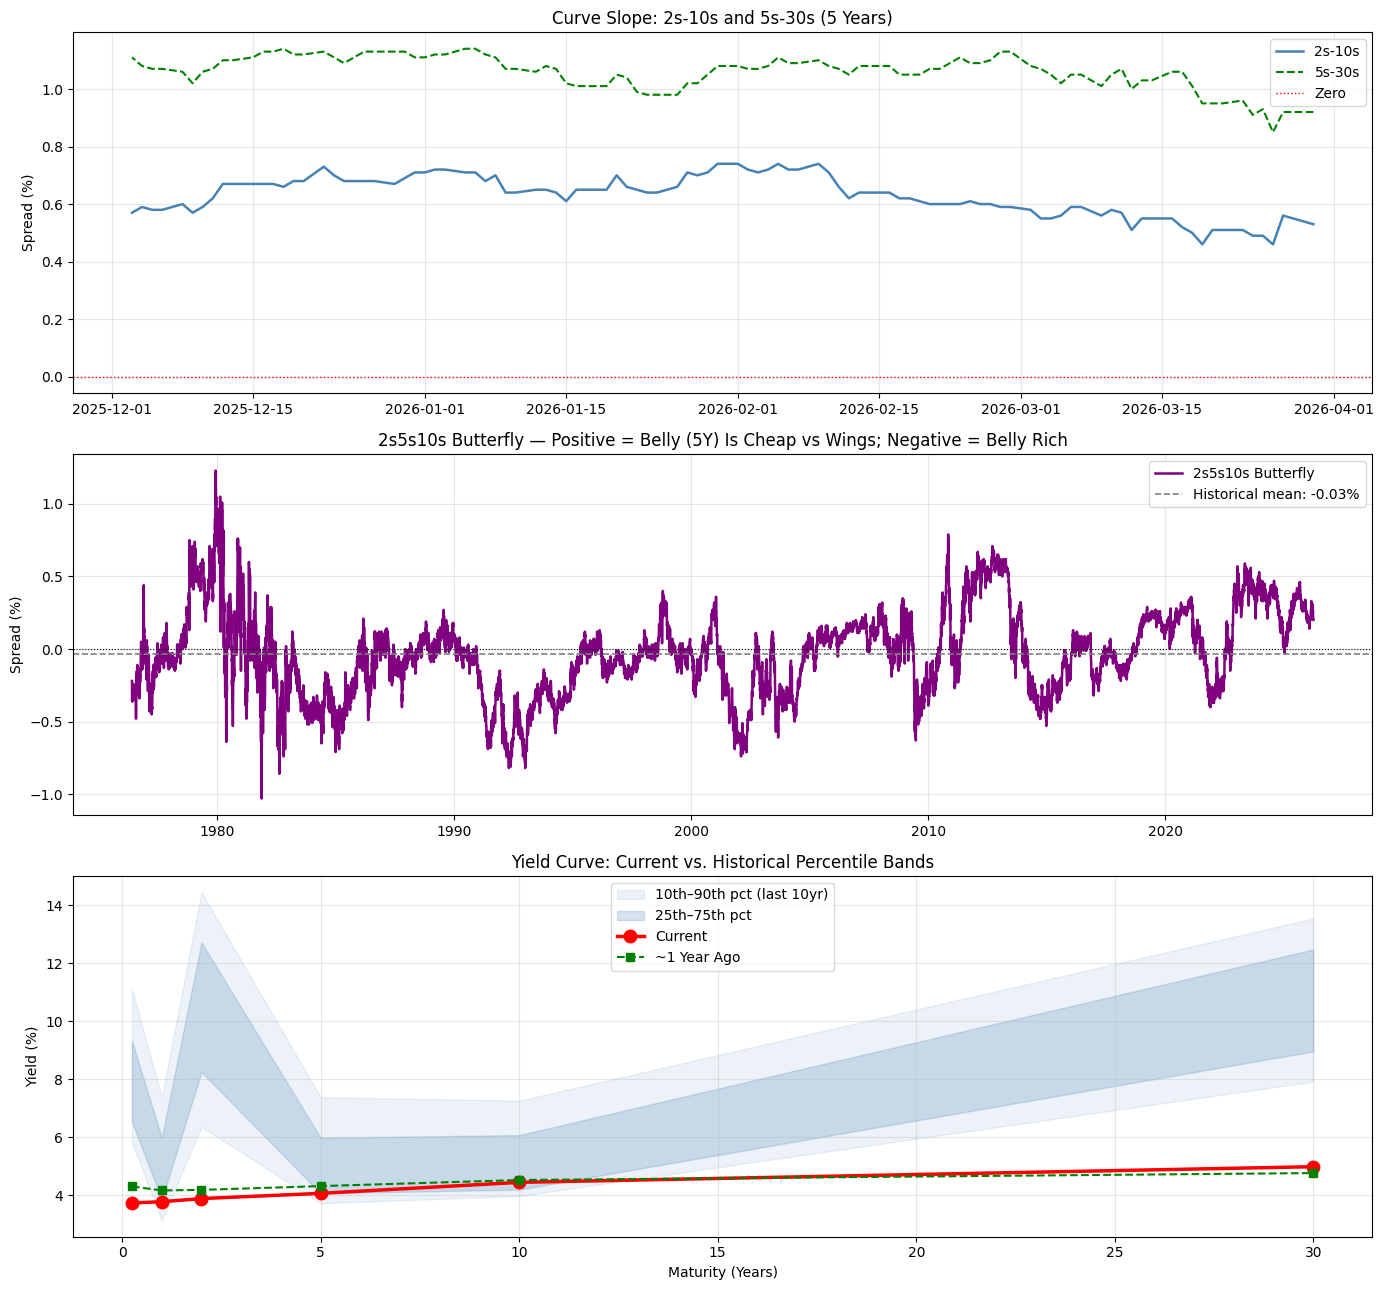


=== Curve Shape Summary ===
2s-10s slope:          +0.68%  (hist mean: +0.85%)
5s-30s slope:          +0.98%  (hist mean: +0.79%)
2s5s10s butterfly:     -0.22%  (hist mean: -0.03%)
10Y yield pct rank:    38th percentile vs last 10 years


In [ ]:
# Curve Expectations: slope/butterfly metrics + current curve vs. historical percentile bands
# (requires tenors / labels / maturities / curve_now defined in Opportunities cell above)

slope_2s10s   = df_master['T10Y2Y'].dropna()
slope_5s30s   = (df_master['DGS30'] - df_master['DGS5']).dropna()
butterfly_255 = (df_master['DGS2'] + df_master['DGS10'] - 2*df_master['DGS5']).dropna()

df_metrics = slope_2s10s.to_frame(name='2s-10s').join(slope_5s30s.to_frame(name='5s-30s')).join(butterfly_255.to_frame(name='2s5s10s Butterfly'))
print(df_metrics.head())
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

# Slope panel
axes[0].plot(df_metrics['2s-10s'].index[:900], df_metrics['2s-10s'][:900], color='steelblue', linewidth=1.8, label='2s-10s')
axes[0].plot(df_metrics['5s-30s'].index[:900], df_metrics['5s-30s'][:900], color='green',     linewidth=1.5, linestyle='--', label='5s-30s')
axes[0].axhline(0, color='red', linewidth=1, linestyle=':', label='Zero')
axes[0].set_title("Curve Slope: 2s-10s and 5s-30s (5 Years)")
axes[0].set_ylabel("Spread (%)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Butterfly panel
axes[1].plot(df_metrics['2s5s10s Butterfly'].index[:900], df_metrics['2s5s10s Butterfly'][:900], color='purple', linewidth=1.8, label='2s5s10s Butterfly')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle=':')
axes[1].axhline(butterfly_255.mean(), color='gray', linewidth=1.2, linestyle='--',
                label=f'Historical mean: {butterfly_255.mean():.2f}%')
axes[1].set_title("2s5s10s Butterfly — Positive = Belly (5Y) Is Cheap vs Wings; Negative = Belly Rich")
axes[1].set_ylabel("Spread (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Current curve vs. historical percentile bands
tenors_series = {lbl: df_master[t].dropna() for lbl, t in zip(labels, tenors)}
lookback = min(min(len(s) for s in tenors_series.values()), 2520)  # up to 10 years

hist_mat = np.array([
    [tenors_series[lbl].iloc[-lookback + i] for lbl in labels]
    for i in range(lookback)
])

p10 = np.nanpercentile(hist_mat, 10, axis=0)
p25 = np.nanpercentile(hist_mat, 25, axis=0)
p75 = np.nanpercentile(hist_mat, 75, axis=0)
p90 = np.nanpercentile(hist_mat, 90, axis=0)

axes[2].fill_between(maturities, p10, p90, alpha=0.10, color='steelblue', label=f'10th–90th pct (last {lookback//252:.0f}yr)')
axes[2].fill_between(maturities, p25, p75, alpha=0.22, color='steelblue', label='25th–75th pct')
axes[2].plot(maturities, curve_now,  'o-', color='red',   linewidth=2.5, markersize=9, label='Current')
axes[2].plot(maturities, curve_1y,   's--', color='green', linewidth=1.5, markersize=6, label='~1 Year Ago')
axes[2].set_title("Yield Curve: Current vs. Historical Percentile Bands")
axes[2].set_xlabel("Maturity (Years)")
axes[2].set_ylabel("Yield (%)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Curve Shape Summary ===")
print(f"2s-10s slope:          {slope_2s10s.iloc[-1]:+.2f}%  (hist mean: {slope_2s10s.mean():+.2f}%)")
print(f"5s-30s slope:          {slope_5s30s.iloc[-1]:+.2f}%  (hist mean: {slope_5s30s.mean():+.2f}%)")
print(f"2s5s10s butterfly:     {butterfly_255.iloc[-1]:+.2f}%  (hist mean: {butterfly_255.mean():+.2f}%)")

# Percentile rank of current 10Y yield in history
pct_rank_10y = (tenors_series['10Y'] <= curve_now[labels.index('10Y')]).mean() * 100
print(f"10Y yield pct rank:    {pct_rank_10y:.0f}th percentile vs last {lookback//252:.0f} years")

## Spread Comparison
How do the spreads on your asset class look relative to history? 
Where do you believe the spreads will be going? 
Why do you believe this?  
What has caused spreads to be where they currently are? 
Include any charts and graphs to explain your thoughts.

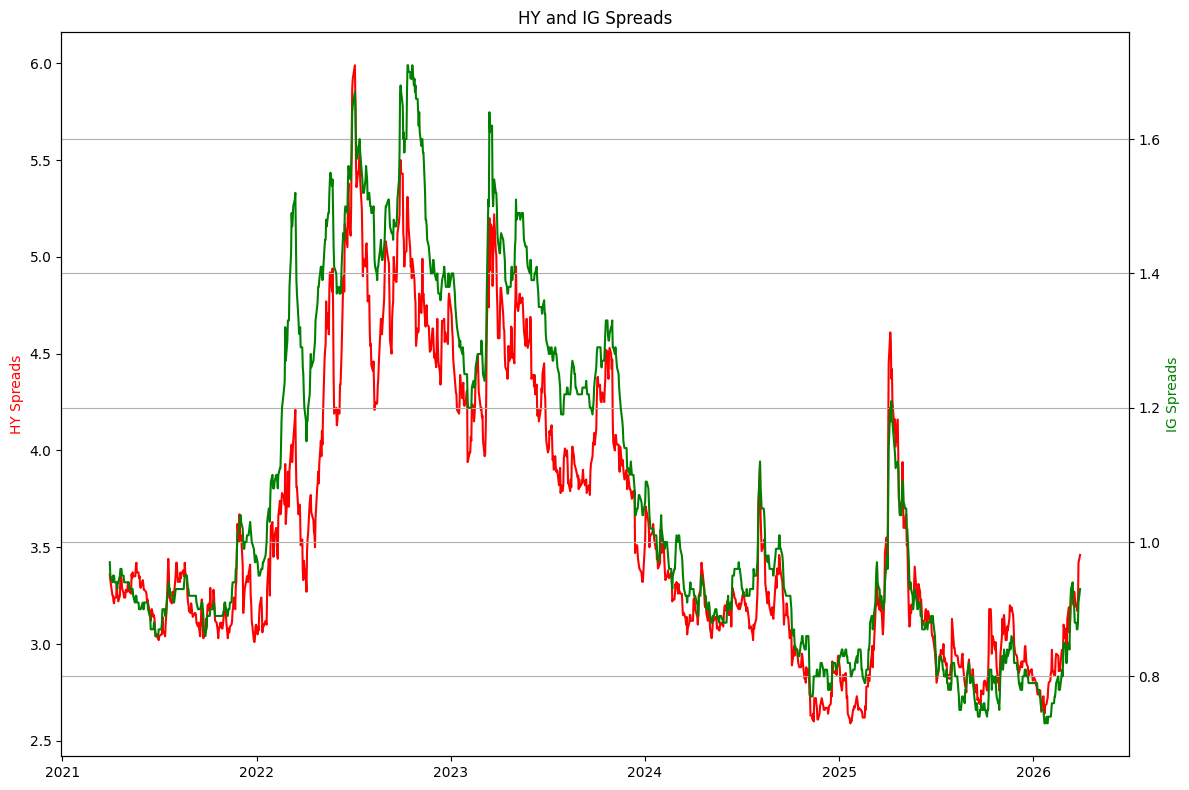

In [9]:
fig, ax1 = plt.subplots(figsize=(12,8))
ax2 = ax1.twinx()
ax1.plot(t_axis, merged["BAMLH0A0HYM2"], color="red", label="HY Spreads")
ax1.set_ylabel("HY Spreads", color="red")
ax2.plot(t_axis, merged["BAMLC0A0CM"], color="green", label="IG Spreads")
ax2.set_ylabel("IG Spreads", color="green")
plt.title("HY and IG Spreads")
fig.tight_layout()
plt.grid()
plt.show();